# Cross-Evaluation: TrOCR (Bentham) → Washington DB

Tests how well the fine-tuned `trocr-base-handwritten` checkpoint (trained on Bentham R0) generalises to the Washington DB — a completely different historical handwritten dataset (George Washington letters, 18th century).

**Dataset:** `washingtondb-v1.0` — 656 binarised line images with ground-truth transcriptions  
**Checkpoint:** `../checkpoints/best/` (best epoch from Bentham training, Val CER 3.44%)  
**Metrics:** Character Error Rate (CER) and Word Error Rate (WER)

## Step 1 — Imports & Setup

In [1]:
import re
from pathlib import Path

import evaluate
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

CHECKPOINT_DIR  = Path("../checkpoints/best_aug")
WASHINGTON_ROOT = Path("../data/washingtondb-v1.0")
IMAGES_DIR      = WASHINGTON_ROOT / "data" / "line_images_normalized"
TRANSCRIPT_FILE = WASHINGTON_ROOT / "ground_truth" / "transcription.txt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Checkpoint: {CHECKPOINT_DIR.resolve()}")
print(f"Images:     {IMAGES_DIR.resolve()}")

Device: cuda
Checkpoint: /home/justin/Ginger_Gradient/14/project/Capstone-Project/checkpoints/best_aug
Images:     /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/washingtondb-v1.0/data/line_images_normalized


## Step 2 — Decode Washington DB Transcriptions

The ground-truth format encodes each word character-by-character:
```
270-01  s_2-s_7-s_0-s_pt|L-e-t-t-e-r-s-s_cm|O-r-d-e-r-s|...
```
Characters are separated by `-`, words by `|`.  
Special tokens: `s_pt`→`.`, `s_cm`→`,`, `s_sq`→`'`, `s_mi`→`-`, `s_s`→`s`, digits `s_0`–`s_9`, ordinals `s_1st` etc.

In [2]:
# Explicit mapping for known special tokens
_SPECIAL = {
    "s_pt": ".", "s_cm": ",", "s_sq": "'", "s_qo": "'",
    "s_qt": "'", "s_mi": "-", "s_s": "s", "s_ss": "ss",
    "s_GW": "GW",
    **{f"s_{d}": str(d) for d in range(10)},
}

def _decode_char(c: str) -> str:
    if not c.startswith("s_"):
        return c
    if c in _SPECIAL:
        return _SPECIAL[c]
    # ordinals like s_1st, s_26th — strip the s_ prefix
    return c[2:]

def decode_line(encoded: str) -> str:
    words = encoded.strip().split("|")
    decoded_words = ["".join(_decode_char(c) for c in w.split("-")) for w in words]
    return " ".join(decoded_words)


# Quick sanity check
example = "s_2-s_7-s_0-s_pt|L-e-t-t-e-r-s-s_cm|O-r-d-e-r-s|a-n-d|I-n-s-t-r-u-c-t-i-o-n-s-s_pt"
print(decode_line(example))  # expected: "270. Letters, Orders and Instructions."

270. Letters, Orders and Instructions.


## Step 3 — Build Image–Transcript DataFrame

In [3]:
records = []
with open(TRANSCRIPT_FILE, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        line_id, encoded = line.split(" ", 1)
        img_path = IMAGES_DIR / f"{line_id}.png"
        if img_path.exists():
            records.append({"line_id": line_id, "image_path": str(img_path), "transcription": decode_line(encoded)})

df = pd.DataFrame(records)
print(f"{len(df)} line image–transcript pairs found")
df.head()

656 line image–transcript pairs found


,line_id,image_path,transcription
0,270-01,../data/washingtondb-v1.0/data/line_images_nor...,"270. Letters, Orders and Instructions. October..."
1,270-03,../data/washingtondb-v1.0/data/line_images_nor...,"only for the publick use, unless by particu-"
2,270-04,../data/washingtondb-v1.0/data/line_images_nor...,lar Orders from me. You are to send
3,270-05,../data/washingtondb-v1.0/data/line_images_nor...,"down a Barrel of Flints with the Arms, to"
4,270-06,../data/washingtondb-v1.0/data/line_images_nor...,"Winchester, and about two thousand weight"


## Step 4 — Load Fine-tuned Checkpoint

In [4]:
processor = TrOCRProcessor.from_pretrained(CHECKPOINT_DIR)
model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)
model.eval()
print("Checkpoint loaded.")

Checkpoint loaded.


## Step 5 — Dataset & DataLoader

In [5]:
class WashingtonDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels, "line_id": row["line_id"]}


dataset = WashingtonDataset(df, processor)
loader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=0)
print(f"{len(dataset)} samples, {len(loader)} batches")

656 samples, 41 batches


## Step 6 — Run Inference

In [6]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

all_preds, all_refs, all_ids = [], [], []

with torch.no_grad():
    for batch in tqdm(loader, desc="Inference"):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].clone()

        generated_ids = model.generate(pixel_values, max_new_tokens=128)
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

        labels[labels == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(labels, skip_special_tokens=True)

        all_preds.extend(preds)
        all_refs.extend(refs)
        all_ids.extend(batch["line_id"])

cer = cer_metric.compute(predictions=all_preds, references=all_refs)
wer = wer_metric.compute(predictions=all_preds, references=all_refs)

print(f"\nCross-Evaluation Results (Washington DB, n={len(all_preds)})")
print(f"  CER: {cer:.4f} ({cer*100:.2f}%)")
print(f"  WER: {wer:.4f} ({wer*100:.2f}%)")

Inference:   0%|          | 0/41 [00:00<?, ?it/s]


Cross-Evaluation Results (Washington DB, n=656)
  CER: 0.1604 (16.04%)
  WER: 0.3711 (37.11%)


## Step 7 — Inspect Predictions

In [7]:
results_df = pd.DataFrame({"line_id": all_ids, "reference": all_refs, "prediction": all_preds})

# Per-line CER for sorting
results_df["line_cer"] = results_df.apply(
    lambda r: cer_metric.compute(predictions=[r["prediction"]], references=[r["reference"]]),
    axis=1,
)

print("=== 10 best lines (lowest CER) ===")
display(results_df.sort_values("line_cer").head(10)[["line_id", "reference", "prediction", "line_cer"]])

print("\n=== 10 worst lines (highest CER) ===")
display(results_df.sort_values("line_cer", ascending=False).head(10)[["line_id", "reference", "prediction", "line_cer"]])

=== 10 best lines (lowest CER) ===


,line_id,reference,prediction,line_cer
225,276-32,"turn to their respective Companies, so soon as","turn to their respective Companies, so soon as",0.0
281,278-22,"necessary that you should, after paying the","necessary that you should, after paying the",0.0
522,305-32,As a quantity of Salt is wanted at,As a quantity of Salt is wanted at,0.0
615,308-27,So soon as the Vessel with the,So soon as the Vessel with the,0.0
614,308-26,Regiment.,Regiment.,0.0
184,275-23,give such directions as you shall see necessar...,give such directions as you shall see necessar...,0.0
344,300-23,informing me that all was peaceable,informing me that all was peaceable,0.0
345,300-24,"above, and that nothing was so imme-","above, and that nothing was so imme-",0.0
42,271-14,"for your recruiting money, before you leave him.","for your recruiting money, before you leave him.",0.0
130,274-01,"274. Letters, Orders and Instructions. October...","274. Letters, Orders and Instructions. October...",0.0



=== 10 worst lines (highest CER) ===


,line_id,reference,prediction,line_cer
319,279-27,GW,9.19.,2.500000
465,304-08,GW,Lizzo,2.500000
260,277-34,mand,trouserve,2.250000
513,305-22,GW,£11.,2.000000
333,300-11,GW,Five,2.000000
244,277-17,GW,""" so",2.000000
262,277-36,GW,The,1.500000
67,272-06,"Sir,",5.000.,1.500000
564,307-07,morrow.,""" sometimes",1.428571
7,270-09,"Captain Ashby and Company, at the",""" <gap/> <gap/> <gap/> <gap/> <gap/> ...",1.393939


## Step 8 — CER Distribution

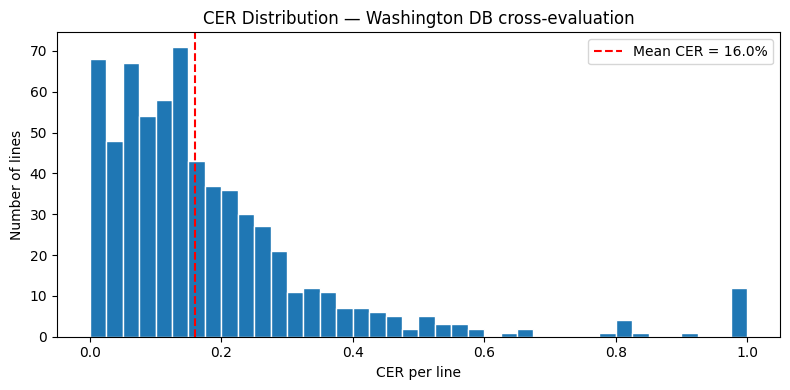

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results_df["line_cer"].clip(upper=1.0), bins=40, edgecolor="white")
ax.axvline(cer, color="red", linestyle="--", label=f"Mean CER = {cer*100:.1f}%")
ax.set_xlabel("CER per line")
ax.set_ylabel("Number of lines")
ax.set_title("CER Distribution — Washington DB cross-evaluation")
ax.legend()
plt.tight_layout()
plt.show()